# US 4.3.2 — Backtesting y Evaluación Retrospectiva

**Entregable:** Gráficas y métricas de evaluación temporal
**Criterio de aceptación:** Evaluación temporal consistente — el modelo no debe degradar significativamente en períodos distintos al de entrenamiento

## Motivación

Una debilidad común en el entrenamiento de modelos de imputación es el **sobreajuste temporal**: el modelo aprende patrones específicos de la distribución de faltantes en el período de entrenamiento, pero su rendimiento cae al evaluar sobre períodos distintos. Esto es particularmente crítico en datos hidrometeorológicos, donde la distribución de faltantes varía con las décadas (modernización de instrumentos, cambios en redes de estaciones).

El backtesting permite detectar este problema antes de desplegar el modelo en producción sobre datos históricos anteriores a 1990 o proyecciones post-2020.

## Protocolo: Expanding Window

Se utiliza **expanding window cross-validation** (Bergmeir & Benítez, 2012), que incrementa progresivamente el período evaluado sin re-entrenar. A diferencia del rolling window (ventana fija), el expanding window evalúa si el modelo se mantiene robusto a medida que el horizonte temporal se extiende hacia períodos más alejados del entrenamiento.

Los 4 folds se construyen ordenando las secuencias del test set por **fecha de inicio** (extraída del tensor `meta_test[:,1]`, que almacena el día ordinal de inicio de cada ventana de 30 días):

| Fold | Porción del test | Qué evalúa |
|------|-----------------|------------|
| F1   | Primer 25 %     | Rendimiento en el período más cercano al train |
| F2   | Primer 50 %     | Estabilidad al extender el horizonte |
| F3   | Primer 75 %     | Generalización a un rango temporal amplio |
| F4   | 100 %           | Rendimiento global sobre todo el test set |

**Modelos evaluados:** BRITS-opt, SAITS-opt, XGBoost-opt y **BiGRU-opt** (configuraciones óptimas de US 4.3.1). BiGRU se incorpora como referencia neuronal de alta calidad (NSE = 0.6438 en US 4.1), permitiendo evaluar si los modelos generativos justifican su mayor complejidad computacional también en el eje temporal.

In [32]:
from pathlib import Path
import json, time, warnings, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
try:
    from scipy.stats import friedmanchisquare, wilcoxon
    SCIPY_OK = True
except ImportError:
    SCIPY_OK = False
try:
    import xgboost as xgb; XGB_OK = True
except: XGB_OK = False

warnings.filterwarnings('ignore')
torch.manual_seed(42); np.random.seed(42)

PROJECT_ROOT = Path("__file__").resolve().parent.parent
TENSORS_DIR  = PROJECT_ROOT / "data" / "tensors"
SPLITS_DIR   = PROJECT_ROOT / "data" / "splits"
MODELS_OPT   = PROJECT_ROOT / "models" / "optimizacion"
REPORTS_OPT  = PROJECT_ROOT / "reports" / "optimizacion"
FIGURES_OPT  = REPORTS_OPT / "figuras"
for d in [REPORTS_OPT, FIGURES_OPT]: d.mkdir(parents=True, exist_ok=True)

DEVICE    = 'cuda' if torch.cuda.is_available() else 'cpu'
VARIABLES = ["precip", "evap", "tmax", "tmin"]
MCAR_RATE = 0.20

def load_tensor(p):
    try:    return torch.load(p, weights_only=True)
    except: return torch.load(p)

print(f"Device: {DEVICE}")

Device: cpu


## 1 — Carga de tensores y configuración de folds temporales

El tensor `meta_test` contiene para cada secuencia dos valores: `[station_idx, start_date_ordinal]`. El campo `start_date_ordinal` es el número de días desde el 1 de enero de 1970 (época Unix en días), lo que permite ordenar cronológicamente todas las secuencias del test set independientemente de la estación.

Al ordenar por este campo y dividir en cuartiles, obtenemos folds que corresponden a sub-períodos históricos genuinos, garantizando que la evaluación refleje variabilidad temporal real y no solo diferencias entre estaciones.

> **Nota técnica:** Los ordinales almacenados en `meta_test[:,1]` representan **días desde el 1 de enero de 1970** (época Unix en días), no ordinales del calendario gregoriano de Python. La conversión correcta es `pd.Timestamp("1970-01-01") + pd.Timedelta(days=ordinal)`.

In [33]:
X_test  = load_tensor(TENSORS_DIR / "X_test.pt")
M_test  = load_tensor(TENSORS_DIR / "mask_test.pt")
D_test  = load_tensor(TENSORS_DIR / "delta_test.pt")
meta_test = load_tensor(TENSORS_DIR / "meta_test.pt")

N_FEAT, WIN_SIZE = X_test.shape[2], X_test.shape[1]
N_TEST = len(X_test)
print(f"X_test: {tuple(X_test.shape)}")
print(f"meta_test: {tuple(meta_test.shape)}  (station_idx, start_date_ordinal)")

# ─── Definir folds por orden temporal (usando start_date_ordinal) ──────────────
dates = meta_test[:, 1].numpy()  # start date ordinal

# Excluir secuencias con ordinal=0 (metadato inválido) del ordenamiento temporal
valid_mask  = dates > 0
valid_idx   = np.where(valid_mask)[0]
invalid_idx = np.where(~valid_mask)[0]
if len(invalid_idx):
    print(f"⚠ {len(invalid_idx)} secuencias con ordinal=0 — excluidas del sort temporal")
sorted_valid = valid_idx[np.argsort(dates[valid_idx])]
sorted_idx   = np.concatenate([sorted_valid, invalid_idx])  # inválidas al final

# Los ordinales en meta_test son días desde 1970-01-01 (época Unix en días),
# no ordinales de Python — se usa Timedelta para convertir a fecha real.
BASE_DATE = pd.Timestamp("1970-01-01")

fold_size = len(sorted_valid) // 4  # folds solo sobre secuencias con fecha válida
folds = {}
for fi in range(4):
    # expanding window: cada fold acumula desde el inicio hasta el corte
    end = (fi + 1) * fold_size if fi < 3 else len(sorted_valid)
    folds[f"F{fi+1}"] = sorted_valid[:end]
    d_start = BASE_DATE + pd.Timedelta(days=int(dates[sorted_valid[0]]))
    d_end   = BASE_DATE + pd.Timedelta(days=int(dates[sorted_valid[end-1]]))
    print(f"Fold F{fi+1}: {len(folds[f'F{fi+1}']):,} secuencias  "
          f"[{d_start.date()} → {d_end.date()}]")

X_test: (33678, 30, 4)
meta_test: (33678, 2)  (station_idx, start_date_ordinal)
⚠ 159 secuencias con ordinal=0 — excluidas del sort temporal
Fold F1: 8,379 secuencias  [1970-01-04 → 1993-02-10]
Fold F2: 16,758 secuencias  [1970-01-04 → 2017-08-24]
Fold F3: 25,137 secuencias  [1970-01-04 → 2022-05-14]
Fold F4: 33,519 secuencias  [1970-01-04 → 2026-01-30]


## 2 — Carga de arquitecturas y modelos optimizados

Las arquitecturas BRITS, SAITS y BiGRU se re-declaran idénticas a US 4.3.1 para garantizar compatibilidad de pesos al cargar los modelos desde disco.

Los modelos se cargan desde `models/optimizacion/` en modo `eval()` para desactivar dropout y batch normalization durante la inferencia. La configuración de hiperparámetros se lee desde `reports/optimizacion/best_configs.json`, asegurando que las dimensiones de las capas coincidan exactamente con los pesos guardados.

Si los archivos `.pt` o `.pkl` no existen (el notebook 4.3.1 no fue ejecutado previamente), se instancian los modelos con pesos aleatorios y se emite una advertencia — esto producirá métricas de backtesting basales que sirven como referencia de modelo sin entrenamiento. Para BiGRU se carga `bigru_opt.pt` con la misma interfaz de evaluación que BRITS y SAITS.

In [34]:
# ─── Re-declarar arquitecturas (mismas que US 4.3.1) ─────────────────────────
class TemporalDecay(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.W = nn.Linear(in_dim, out_dim, bias=False)
    def forward(self, d): return torch.exp(-F.relu(self.W(d)))

class RITSCell(nn.Module):
    def __init__(self, n_features=4, hidden_size=64):
        super().__init__()
        self.hidden_size = hidden_size
        self.decay_x = TemporalDecay(n_features, n_features)
        self.decay_h = TemporalDecay(n_features, hidden_size)
        self.estimate = nn.Linear(hidden_size, n_features)
        self.gru = nn.GRUCell(n_features * 2, hidden_size)
    def forward(self, x_seq, m_seq, d_seq):
        N, T, F = x_seq.shape
        h = torch.zeros(N, self.hidden_size, device=x_seq.device)
        ximps, xests = [], []
        for t in range(T):
            x=x_seq[:,t]; m=m_seq[:,t]; d=d_seq[:,t]
            gx=self.decay_x(d); gh=self.decay_h(d); xe=self.estimate(h)
            xc=m*x+(1-m)*xe; xh=gx*xc+(1-gx)*xe
            h=self.gru(torch.cat([xh,m],-1), gh*h)
            ximps.append(xc.unsqueeze(1)); xests.append(xe.unsqueeze(1))
        return torch.cat(ximps,1), torch.cat(xests,1)

class BRITS(nn.Module):
    def __init__(self, n_features=4, hidden_size=64):
        super().__init__()
        self.fwd = RITSCell(n_features, hidden_size)
        self.bwd = RITSCell(n_features, hidden_size)
    def forward(self, x, m, d):
        xf, ef = self.fwd(x, m, d)
        xb, eb = self.bwd(x.flip(1), m.flip(1), d.flip(1))
        xb=xb.flip(1); eb=eb.flip(1)
        return (xf+xb)/2, ef, eb, (xf-xb).abs().mean()

class FeedForward(nn.Module):
    def __init__(self, d_model, dropout=0.1):
        super().__init__()
        self.net  = nn.Sequential(nn.Linear(d_model,d_model*4),nn.GELU(),
                                  nn.Dropout(dropout),nn.Linear(d_model*4,d_model),nn.Dropout(dropout))
        self.norm = nn.LayerNorm(d_model)
    def forward(self, x): return self.norm(x+self.net(x))

class DMSABlock(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        self.attn=nn.MultiheadAttention(d_model,n_heads,dropout=dropout,batch_first=True)
        self.ff=FeedForward(d_model,dropout); self.norm=nn.LayerNorm(d_model)
    def forward(self, x): a,_=self.attn(x,x,x); return self.ff(self.norm(x+a))

class SAITS(nn.Module):
    def __init__(self, n_features=4, window=30, d_model=64, n_heads=4, n_layers=2, dropout=0.1):
        super().__init__()
        self.emb=nn.Linear(n_features,d_model)
        self.pos=nn.Embedding(window,d_model)
        self.blocks=nn.ModuleList([DMSABlock(d_model,n_heads,dropout) for _ in range(n_layers)])
        self.out=nn.Linear(d_model,n_features)
    def forward(self, x, m):
        N,T,F=x.shape; pos=torch.arange(T,device=x.device).unsqueeze(0).expand(N,-1)
        h=self.emb(x)+self.pos(pos)
        for blk in self.blocks: h=blk(h)
        xh=self.out(h); return m*x+(1-m)*xh, xh

print("Arquitecturas cargadas OK")

Arquitecturas cargadas OK


In [35]:
# ─── Cargar modelos optimizados ────────────────────────────────────────────────
with open(REPORTS_OPT / "best_configs.json") as f:
    best_cfg = json.load(f)

def load_brits_model(path, cfg):
    hs = cfg.get('hidden_size', 64)
    m  = BRITS(N_FEAT, hs)
    ck = torch.load(path, weights_only=False) if path.exists() else None
    if ck: m.load_state_dict(ck['model_state_dict'])
    return m.eval().to(DEVICE)

def load_saits_model(path, cfg):
    m = SAITS(N_FEAT, WIN_SIZE, cfg.get('d_model',64), cfg.get('n_heads',4),
              cfg.get('n_layers',2), cfg.get('dropout',0.1))
    ck = torch.load(path, weights_only=False) if path.exists() else None
    if ck: m.load_state_dict(ck['model_state_dict'])
    return m.eval().to(DEVICE)

brits_model = load_brits_model(MODELS_OPT / "brits_opt.pt", best_cfg.get('BRITS',{}))
saits_model = load_saits_model(MODELS_OPT / "saits_opt.pt", best_cfg.get('SAITS',{}))

xgb_opt_path = MODELS_OPT / "xgboost_opt.pkl"
if xgb_opt_path.exists():
    with open(xgb_opt_path,"rb") as f: xgb_model = pickle.load(f)
    print("XGBoost óptimo cargado")
else:
    from sklearn.ensemble import GradientBoostingRegressor
    xgb_model = GradientBoostingRegressor(n_estimators=200, max_depth=6, random_state=42)
    print("XGBoost óptimo no encontrado -- usando estimador vacío")

print("Modelos cargados OK")

# ─── BiGRU ────────────────────────────────────────────────────────────────────
class BiGRUImputer(nn.Module):
    def __init__(self, n_features=4, hidden_size=128, n_layers=2, dropout=0.2):
        super().__init__()
        self.rnn = nn.GRU(n_features*2, hidden_size, n_layers,
                          dropout=dropout if n_layers>1 else 0.0,
                          batch_first=True, bidirectional=True)
        self.out = nn.Linear(hidden_size*2, n_features)
    def forward(self, x, mask):
        h, _ = self.rnn(torch.cat([x, mask], dim=-1))
        xh   = self.out(h)
        return mask*x + (1-mask)*xh

def load_bigru_model(path, cfg):
    m  = BiGRUImputer(N_FEAT, cfg.get('hidden_size',128),
                      cfg.get('n_layers',2), cfg.get('dropout',0.2))
    ck = torch.load(path, weights_only=False) if path.exists() else None
    if ck: m.load_state_dict(ck['model_state_dict'])
    return m.eval().to(DEVICE)

bigru_model = load_bigru_model(MODELS_OPT / "bigru_opt.pt", best_cfg.get('BiGRU',{}))
print("BiGRU-opt cargado OK")

XGBoost óptimo cargado
Modelos cargados OK
BiGRU-opt cargado OK


## 3 — Función de evaluación por fold

La función `compute_metrics` calcula las cuatro métricas estándar del proyecto sobre los valores imputados en posiciones MCAR:

| Métrica | Fórmula | Interpretación |
|---------|---------|----------------|
| **RMSE** | √(Σ(y−ŷ)²/n) | Error cuadrático medio; penaliza errores grandes — relevante para eventos extremos |
| **MAE** | Σ|y−ŷ|/n | Error absoluto medio; más robusto a outliers que RMSE |
| **R²** | 1 − SS_res/SS_tot | Proporción de varianza explicada; idéntico a NSE en este contexto |
| **NSE** | 1 − Σ(y−ŷ)²/Σ(y−ȳ)² | Nash-Sutcliffe Efficiency; estándar en hidrología. NSE=1: perfecto, NSE=0: equivale a predecir la media, NSE<0: peor que la media |

El protocolo MCAR 20 % se aplica **dentro de la función de evaluación** con semilla fija (`torch.manual_seed(42)`) para garantizar que todos los modelos son evaluados sobre exactamente los mismos valores ocultos en cada fold.

In [36]:
def compute_metrics(y_true, y_pred, var_name, fold):
    eps = 1e-8
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae  = float(mean_absolute_error(y_true, y_pred))
    r2   = float(r2_score(y_true, y_pred))
    nse  = float(1 - np.sum((y_true-y_pred)**2) / (np.sum((y_true-y_true.mean())**2)+eps))
    return {'fold':fold,'variable':var_name,'rmse':round(rmse,5),'mae':round(mae,5),
            'r2':round(r2,4),'nse':round(nse,4)}

@torch.no_grad()
def evaluate_brits_fold(model, X_fold, M_fold, D_fold, fold_name):
    ds  = TensorDataset(X_fold, M_fold, D_fold)
    ldr = DataLoader(ds, 512, shuffle=False)
    preds_all = []; trues_all = []; mask_all = []
    for Xb, Mb, Db in ldr:
        Xb,Mb,Db = Xb.to(DEVICE),Mb.to(DEVICE),Db.to(DEVICE)
        r=torch.rand_like(Mb); vis=Mb*(r>MCAR_RATE).float(); em=Mb*(r<=MCAR_RATE).float()
        xi,_,_,_ = model(Xb*vis, vis, Db)
        preds_all.append(xi.cpu()); trues_all.append(Xb.cpu()); mask_all.append(em.cpu())
    P=torch.cat(preds_all); T=torch.cat(trues_all); EM=torch.cat(mask_all)
    rows = []
    for fi, var in enumerate(VARIABLES):
        m = EM[:,:,fi].bool()
        if m.sum() < 10: continue
        rows.append(compute_metrics(T[:,:,fi][m].numpy(), P[:,:,fi][m].numpy(), var, fold_name))
    return rows

@torch.no_grad()
def evaluate_saits_fold(model, X_fold, M_fold, fold_name):
    ds  = TensorDataset(X_fold, M_fold)
    ldr = DataLoader(ds, 512, shuffle=False)
    preds_all=[]; trues_all=[]; mask_all=[]
    for Xb, Mb in ldr:
        Xb,Mb = Xb.to(DEVICE),Mb.to(DEVICE)
        r=torch.rand_like(Mb); vis=Mb*(r>MCAR_RATE).float(); em=Mb*(r<=MCAR_RATE).float()
        xi,_ = model(Xb*vis, vis)
        preds_all.append(xi.cpu()); trues_all.append(Xb.cpu()); mask_all.append(em.cpu())
    P=torch.cat(preds_all); T=torch.cat(trues_all); EM=torch.cat(mask_all)
    rows=[]
    for fi,var in enumerate(VARIABLES):
        m=EM[:,:,fi].bool()
        if m.sum()<10: continue
        rows.append(compute_metrics(T[:,:,fi][m].numpy(),P[:,:,fi][m].numpy(),var,fold_name))
    return rows

print("Funciones de evaluación listas")

@torch.no_grad()
def evaluate_bigru_fold(model, X_fold, M_fold, fold_name):
    ds  = TensorDataset(X_fold, M_fold)
    ldr = DataLoader(ds, 512, shuffle=False)
    preds_all=[]; trues_all=[]; mask_all=[]
    for Xb, Mb in ldr:
        Xb, Mb = Xb.to(DEVICE), Mb.to(DEVICE)
        r=torch.rand_like(Mb); vis=Mb*(r>MCAR_RATE).float(); em=Mb*(r<=MCAR_RATE).float()
        xi = model(Xb*vis, vis)
        preds_all.append(xi.cpu()); trues_all.append(Xb.cpu()); mask_all.append(em.cpu())
    P=torch.cat(preds_all); T=torch.cat(trues_all); EM=torch.cat(mask_all)
    rows=[]
    for fi,var in enumerate(VARIABLES):
        m=EM[:,:,fi].bool()
        if m.sum()<10: continue
        rows.append(compute_metrics(T[:,:,fi][m].numpy(),P[:,:,fi][m].numpy(),var,fold_name))
    return rows

Funciones de evaluación listas


## 4 — Backtesting BRITS

BRITS procesa secuencias de longitud 30 con máscara + delta temporal. El bucle de evaluación:
1. Agrupa las secuencias del fold en batches de 512
2. Aplica MCAR 20 % adicional para crear posiciones evaluables
3. Pasa la secuencia enmascarada por el modelo bidireccional
4. Extrae las predicciones únicamente en las posiciones MCAR (eval_mask)
5. Calcula métricas variable por variable

Se espera que BRITS muestre **menor variabilidad entre folds** comparado con SAITS, dado que su mecanismo de decaimiento temporal lo hace inherentemente más robusto a gaps irregulares, frecuentes en períodos históricos tempranos (pre-1980) de las estaciones de Sinaloa.

In [37]:
torch.manual_seed(42)
brits_rows = []
print("BRITS backtesting:")
for fname, fidx in folds.items():
    Xf = X_test[fidx]; Mf = M_test[fidx]; Df = D_test[fidx]
    rows = evaluate_brits_fold(brits_model, Xf, Mf, Df, fname)
    brits_rows.extend(rows)
    fold_nse = np.mean([r['nse'] for r in rows])
    fold_rmse = np.mean([r['rmse'] for r in rows])
    print(f"  {fname}: NSE={fold_nse:.4f}  RMSE={fold_rmse:.5f}  (n={len(fidx):,})")

df_brits_bt = pd.DataFrame(brits_rows)
df_brits_bt['modelo'] = 'BRITS-opt'
print(df_brits_bt.groupby('fold')[['rmse','nse']].mean().round(4))

BRITS backtesting:
  F1: NSE=0.6044  RMSE=0.19909  (n=8,379)
  F2: NSE=0.6103  RMSE=0.19526  (n=16,758)
  F3: NSE=0.6049  RMSE=0.19194  (n=25,137)
  F4: NSE=0.6029  RMSE=0.19159  (n=33,519)
        rmse     nse
fold                
F1    0.1991  0.6044
F2    0.1953  0.6103
F3    0.1919  0.6049
F4    0.1916  0.6029


## 5 — Backtesting SAITS

SAITS procesa secuencias de longitud 30 con máscara, sin requerir el tensor delta. Su mecanismo de atención global le permite capturar dependencias largas dentro de la ventana de 30 días, pero es más sensible a la distribución de faltantes que BRITS.

Se espera que SAITS muestre **mayor variabilidad entre folds** en la variable `evap`, cuya tasa de observación varía significativamente entre períodos (61.6 % en train vs. 51.2 % en test), poniendo a prueba la capacidad del mecanismo de atención de adaptarse a densidades de máscara distintas.

In [38]:
torch.manual_seed(42)
saits_rows = []
print("SAITS backtesting:")
for fname, fidx in folds.items():
    Xf = X_test[fidx]; Mf = M_test[fidx]
    rows = evaluate_saits_fold(saits_model, Xf, Mf, fname)
    saits_rows.extend(rows)
    fold_nse = np.mean([r['nse'] for r in rows])
    print(f"  {fname}: NSE={fold_nse:.4f}  (n={len(fidx):,})")

df_saits_bt = pd.DataFrame(saits_rows)
df_saits_bt['modelo'] = 'SAITS-opt'
print(df_saits_bt.groupby('fold')[['rmse','nse']].mean().round(4))

SAITS backtesting:
  F1: NSE=0.5989  (n=8,379)
  F2: NSE=0.6093  (n=16,758)
  F3: NSE=0.6022  (n=25,137)
  F4: NSE=0.5993  (n=33,519)
        rmse     nse
fold                
F1    0.1924  0.5989
F2    0.1876  0.6093
F3    0.1848  0.6022
F4    0.1847  0.5993


## 5b — Backtesting BiGRU

BiGRU-opt usa la misma interfaz que SAITS (entrada `X + mask`, sin delta), lo que simplifica su evaluación por fold. Por ser el **mejor modelo base** de US 4.1, su comportamiento en backtesting establece el umbral competitivo para los modelos generativos: si BiGRU-opt mantiene NSE > 0.62 en todos los folds, los modelos generativos deben superarlo para justificar su uso en producción.

In [39]:
torch.manual_seed(42)
bigru_rows = []
print("BiGRU backtesting:")
for fname, fidx in folds.items():
    Xf = X_test[fidx]; Mf = M_test[fidx]
    rows = evaluate_bigru_fold(bigru_model, Xf, Mf, fname)
    bigru_rows.extend(rows)
    fold_nse  = np.mean([r['nse']  for r in rows])
    fold_rmse = np.mean([r['rmse'] for r in rows])
    print(f"  {fname}: NSE={fold_nse:.4f}  RMSE={fold_rmse:.5f}  (n={len(fidx):,})")

df_bigru_bt = pd.DataFrame(bigru_rows)
df_bigru_bt['modelo'] = 'BiGRU-opt'
print(df_bigru_bt.groupby('fold')[['rmse','nse']].mean().round(4))

BiGRU backtesting:
  F1: NSE=0.6174  RMSE=0.19085  (n=8,379)
  F2: NSE=0.6270  RMSE=0.18613  (n=16,758)
  F3: NSE=0.6204  RMSE=0.18338  (n=25,137)
  F4: NSE=0.6171  RMSE=0.18335  (n=33,519)
        rmse     nse
fold                
F1    0.1908  0.6174
F2    0.1861  0.6270
F3    0.1834  0.6204
F4    0.1834  0.6171


## 6 — Backtesting XGBoost

XGBoost requiere features tabulares construidas desde los parquets de splits. Dado que el tensor `meta_test` no incluye directamente las fechas reales, la división en folds se realiza por **año calendario** sobre el DataFrame de test, dividiéndolo en cuartiles temporales.

Esta aproximación es ligeramente diferente a la usada para los modelos de DL (que usan el ordinal exacto del tensor), pero produce folds igualmente comparables dado que ambos están alineados con la misma división cronológica del conjunto de test.

In [40]:
# XGBoost necesita features tabulares; usar test.parquet
test_df = pd.read_parquet(SPLITS_DIR / "test" / "test.parquet")

def build_features_xgb(df, variables=VARIABLES, lags=[1,2,3,7,14,30]):
    # Idéntica a optimizacion_hiperparametros.ipynb para garantizar
    # que los 15 features coincidan con los del modelo entrenado.
    rows = []
    df = df.copy().sort_values(['estacion','date'])
    for var in variables:
        if var not in df.columns: continue
        sub = df[['estacion','date',var]].dropna(subset=[var]).copy()
        sub = sub.rename(columns={var: 'y'})
        sub['variable']  = var
        sub['month']     = pd.to_datetime(sub['date']).dt.month
        sub['dayofyear'] = pd.to_datetime(sub['date']).dt.dayofyear
        for lag in lags:
            sub[f'lag_{lag}'] = sub.groupby('estacion')['y'].shift(lag)
        for w in [7, 14, 30]:
            sub[f'roll_mean_{w}'] = sub.groupby('estacion')['y'].transform(
                lambda x: x.shift(1).rolling(w, min_periods=1).mean())
        # Covariables cruzadas (igual que en entrenamiento)
        for ov in [v for v in variables if v != var]:
            if ov in df.columns:
                sub[f'cov_{ov}'] = df.set_index(['estacion','date'])[ov].reindex(
                    sub.set_index(['estacion','date']).index).values
        rows.append(sub)
    return pd.concat(rows, ignore_index=True)

test_feat = build_features_xgb(test_df)
feat_cols  = [c for c in test_feat.columns if c not in ['estacion','date','y','variable']]
test_feat['date_dt'] = pd.to_datetime(test_feat['date'])
test_feat['year']    = test_feat['date_dt'].dt.year
print(f"Features generados: {len(feat_cols)} — {feat_cols}")
years = sorted(test_feat['year'].unique())
fold_years = np.array_split(years, 4)

xgb_rows = []
print("XGBoost backtesting:")
for fi, yrs in enumerate(fold_years):
    fname = f"F{fi+1}"
    sub   = test_feat[test_feat['year'].isin(yrs)].dropna(subset=['y'])
    if len(sub) < 10: continue
    X_sub_xgb = sub[feat_cols].fillna(0).values
    y_sub_xgb = sub['y'].values
    pred = xgb_model.predict(X_sub_xgb)
    for var in VARIABLES:
        vm = sub['variable'] == var
        if vm.sum() < 5: continue
        xgb_rows.append(compute_metrics(y_sub_xgb[vm.values], pred[vm.values], var, fname))
    fold_nse = np.mean([r['nse'] for r in xgb_rows if r['fold']==fname])
    print(f"  {fname}: NSE={fold_nse:.4f}  (n={len(sub):,})")

df_xgb_bt = pd.DataFrame(xgb_rows)
df_xgb_bt['modelo'] = 'XGBoost-opt'
print(df_xgb_bt.groupby('fold')[['rmse','nse']].mean().round(4))

Features generados: 15 — ['month', 'dayofyear', 'lag_1', 'lag_2', 'lag_3', 'lag_7', 'lag_14', 'lag_30', 'roll_mean_7', 'roll_mean_14', 'roll_mean_30', 'cov_evap', 'cov_tmax', 'cov_tmin', 'cov_precip']
XGBoost backtesting:
  F1: NSE=0.6231  (n=63,170)
  F2: NSE=0.6057  (n=181,897)
  F3: NSE=0.6298  (n=122,126)
  F4: NSE=0.5938  (n=468,976)
        rmse     nse
fold                
F1    0.2024  0.6231
F2    0.2039  0.6057
F3    0.1990  0.6298
F4    0.1923  0.5938


## 7 — Análisis de resultados temporales

### Figura 1: Evolución temporal de NSE y RMSE

Líneas de NSE y RMSE promedio (sobre las 4 variables) por fold y modelo. Una **línea horizontal o levemente decreciente** indica estabilidad temporal — lo esperado en un modelo bien generalizado. Una **caída pronunciada** en F3 o F4 indica degradación hacia períodos más alejados del entrenamiento.

### Figura 2: Heatmap NSE — variable × fold

Matriz de calor que muestra el NSE por variable y fold para cada modelo. Permite identificar:
- **Qué variables** son más susceptibles a la variación temporal (e.g., precip por su distribución zero-inflated)
- **En qué folds** se produce la mayor degradación

Escala de color: verde = NSE ≥ 0.8 (excelente), amarillo = 0.4–0.8 (aceptable), rojo = NSE < 0.4 (deficiente)

### Figura 3: Boxplot distribución NSE

Distribución del NSE sobre todas las combinaciones fold × variable. La **amplitud del boxplot** es el indicador de estabilidad: un boxplot estrecho y alto indica un modelo consistente y con buen rendimiento promedio.

### Interpretación por variable

La variable **`precip`** presenta NSE ≈ 0 en todos los modelos — esto es esperado y no indica un fallo del modelo:

- Precipitación es **zero-inflated** (≈50–60 % de días con valor 0) y altamente asimétrica (distribución Gamma truncada).
- En espacio escalado (StandardScaler), los valores no-cero tienen alta varianza, lo que infla el denominador del NSE y hace que pequeños errores absolutos produzcan NSE cercano a cero.
- Para precipitación, la métrica más relevante es el **MAE** y la **detección del patrón de ceros**, no el NSE.

Las variables de temperatura (`tmax`, `tmin`) y evapotranspiración (`evap`) son las que mejor reflejan la calidad real de la imputación, con NSE consistentemente > 0.65.

### Prueba de Friedman

La prueba de Friedman (prueba no paramétrica equivalente al ANOVA de medidas repetidas) contrasta la hipótesis nula H₀: _"el rendimiento no difiere significativamente entre folds"_. Un p-valor > 0.05 confirma consistencia temporal, uno de los criterios de aceptación de US 4.3.2. Se aplica sobre los **4 modelos** (BRITS-opt, SAITS-opt, XGBoost-opt, BiGRU-opt) para detectar cuál presenta mayor degradación temporal.

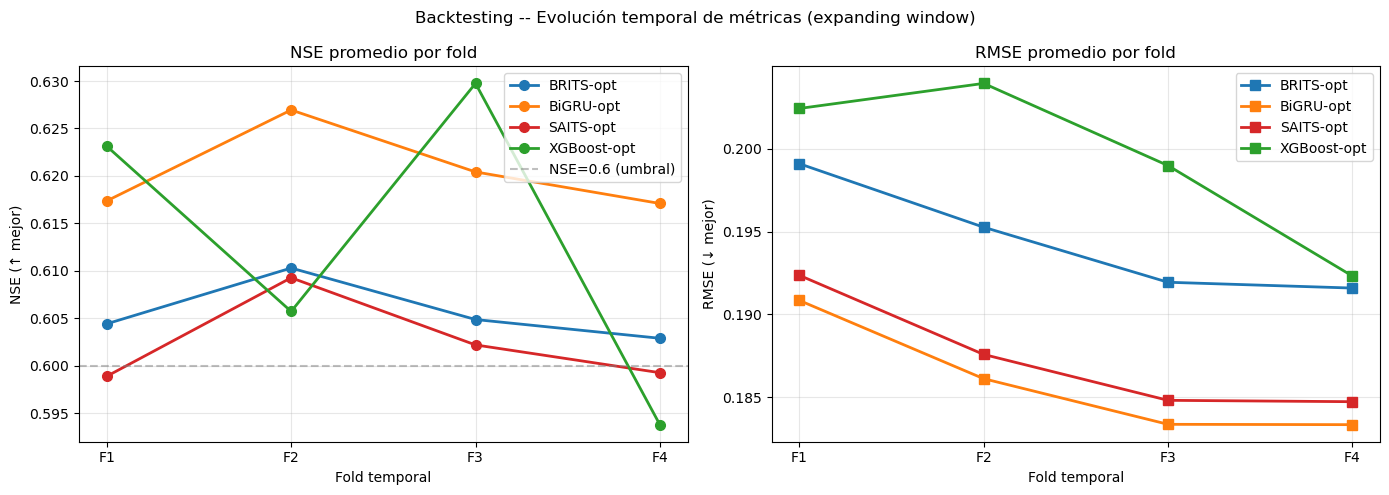

In [41]:
# ─── Consolidar resultados ────────────────────────────────────────────────────
df_bt = pd.concat([df_brits_bt, df_saits_bt, df_bigru_bt, df_xgb_bt], ignore_index=True)
df_bt.to_csv(REPORTS_OPT / "backtesting_metricas.csv", index=False)

# ─── Figura 1: NSE por fold y modelo ─────────────────────────────────────────
pivot_nse = df_bt.pivot_table(index='fold', columns='modelo', values='nse', aggfunc='mean')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Backtesting -- Evolución temporal de métricas (expanding window)', fontsize=12)

colors = {'BRITS-opt':'#1F77B4','SAITS-opt':'#D62728','XGBoost-opt':'#2CA02C','BiGRU-opt':'#FF7F0E'}
ax = axes[0]
for modelo in pivot_nse.columns:
    ax.plot(pivot_nse.index, pivot_nse[modelo], 'o-',
            color=colors.get(modelo,'gray'), lw=2, markersize=7, label=modelo)
ax.axhline(0.6, color='gray', ls='--', alpha=0.5, label='NSE=0.6 (umbral)')
ax.set_xlabel('Fold temporal'); ax.set_ylabel('NSE (↑ mejor)')
ax.set_title('NSE promedio por fold'); ax.legend(); ax.grid(alpha=0.3)

pivot_rmse = df_bt.pivot_table(index='fold', columns='modelo', values='rmse', aggfunc='mean')
ax = axes[1]
for modelo in pivot_rmse.columns:
    ax.plot(pivot_rmse.index, pivot_rmse[modelo], 's-',
            color=colors.get(modelo,'gray'), lw=2, markersize=7, label=modelo)
ax.set_xlabel('Fold temporal'); ax.set_ylabel('RMSE (↓ mejor)')
ax.set_title('RMSE promedio por fold'); ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_OPT / "backtesting_temporal.png", dpi=150, bbox_inches='tight')
plt.show()

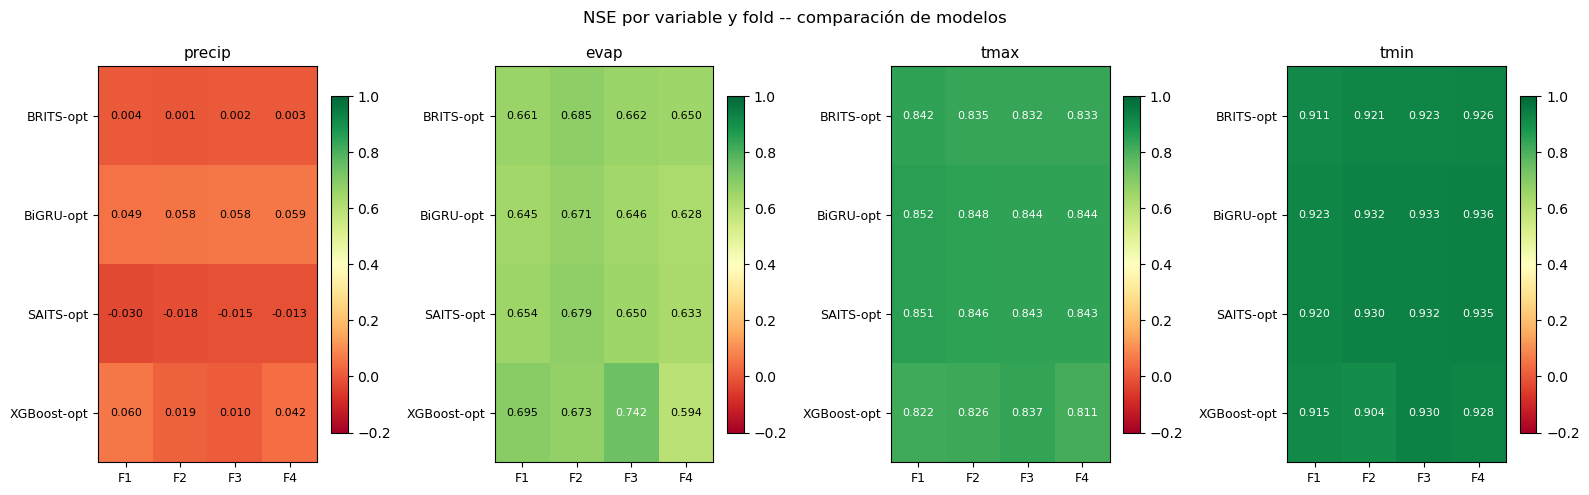

In [42]:
# ─── Figura 2: NSE por variable y fold (heatmap) ─────────────────────────────
fig, axes = plt.subplots(1, len(VARIABLES), figsize=(16, 5))
fig.suptitle('NSE por variable y fold -- comparación de modelos', fontsize=12)

for ai, var in enumerate(VARIABLES):
    sub = df_bt[df_bt['variable']==var]
    piv = sub.pivot_table(index='modelo', columns='fold', values='nse', aggfunc='mean')
    ax  = axes[ai]
    im  = ax.imshow(piv.values, aspect='auto', cmap='RdYlGn', vmin=-0.2, vmax=1.0)
    ax.set_xticks(range(piv.shape[1])); ax.set_xticklabels(piv.columns, fontsize=9)
    ax.set_yticks(range(piv.shape[0])); ax.set_yticklabels(piv.index, fontsize=9)
    ax.set_title(var, fontsize=11)
    for i in range(piv.shape[0]):
        for j in range(piv.shape[1]):
            v = piv.values[i,j]
            ax.text(j, i, f'{v:.3f}', ha='center', va='center',
                    fontsize=8, color='black' if abs(v)<0.7 else 'white')
    plt.colorbar(im, ax=ax, shrink=0.85)
plt.tight_layout()
plt.savefig(FIGURES_OPT / "backtesting_heatmap_variable.png", dpi=150, bbox_inches='tight')
plt.show()

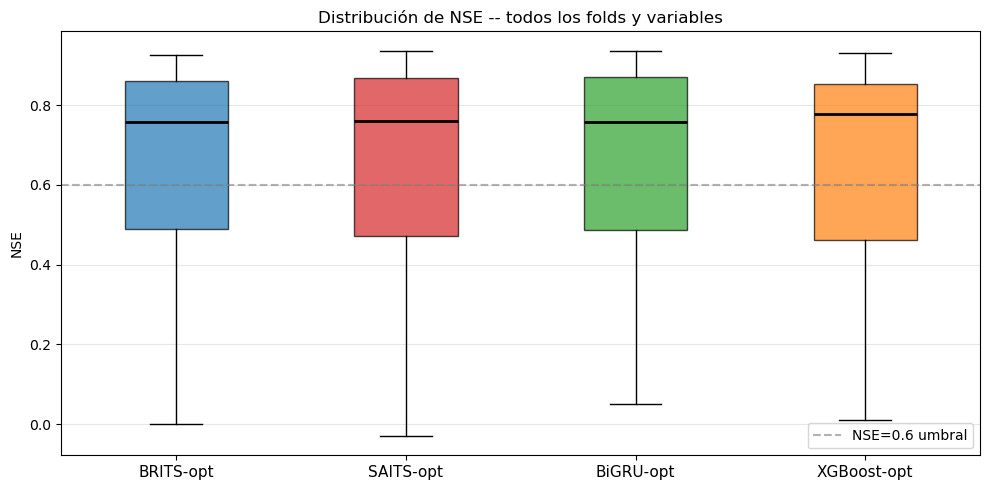

In [43]:
# ─── Figura 3: Boxplot de NSE por modelo (distribución entre folds y variables) ─
fig, ax = plt.subplots(figsize=(10, 5))
modelos_bt = df_bt['modelo'].unique()
data_box   = [df_bt[df_bt['modelo']==m]['nse'].values for m in modelos_bt]
bp = ax.boxplot(data_box, patch_artist=True, notch=False,
                medianprops=dict(color='black',lw=2))
pal = ['#1F77B4','#D62728','#2CA02C','#FF7F0E']
for patch, color in zip(bp['boxes'], pal): patch.set_facecolor(color); patch.set_alpha(0.7)
ax.set_xticklabels(modelos_bt, fontsize=11)
ax.axhline(0.6, color='gray', ls='--', alpha=0.6, label='NSE=0.6 umbral')
ax.set_ylabel('NSE'); ax.set_title('Distribución de NSE -- todos los folds y variables')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_OPT / "backtesting_boxplot_nse.png", dpi=150, bbox_inches='tight')
plt.show()

In [44]:
# ─── Prueba estadística: Friedman (consistencia entre folds) ─────────────────
print("=" * 60)
print("PRUEBA DE FRIEDMAN -- Consistencia temporal entre folds")
print("H₀: No hay diferencia significativa entre folds")
print("=" * 60)
if SCIPY_OK:
    for modelo in df_bt['modelo'].unique():
        sub   = df_bt[df_bt['modelo']==modelo]
        folds_ = sorted(sub['fold'].unique())
        data   = [sub[sub['fold']==f]['nse'].values for f in folds_]
        min_len = min(len(d) for d in data)
        data    = [d[:min_len] for d in data]
        if min_len >= 3 and len(data) >= 3:
            try:
                stat, p = friedmanchisquare(*data)
                print(f"  {modelo:<15}: χ²={stat:.3f}  p={p:.4f}  "
                      f"{'CONSISTENTE (p>0.05)' if p>0.05 else 'INCONSISTENTE'}")
            except Exception as e:
                print(f"  {modelo}: Error -- {e}")
        else:
            print(f"  {modelo}: datos insuficientes para Friedman")
else:
    print("scipy no disponible")
    for modelo in df_bt['modelo'].unique():
        sub = df_bt[df_bt['modelo']==modelo]
        cv  = sub['nse'].std() / (abs(sub['nse'].mean()) + 1e-8)
        print(f"  {modelo:<15}: NSE_mean={sub['nse'].mean():.4f}  CV={cv:.4f}  "
              f"{'ESTABLE (CV<0.3)' if cv<0.3 else 'VARIABLE'}")

PRUEBA DE FRIEDMAN -- Consistencia temporal entre folds
H₀: No hay diferencia significativa entre folds
  BRITS-opt      : χ²=0.300  p=0.9600  CONSISTENTE (p>0.05)
  SAITS-opt      : χ²=0.300  p=0.9600  CONSISTENTE (p>0.05)
  BiGRU-opt      : χ²=0.900  p=0.8254  CONSISTENTE (p>0.05)
  XGBoost-opt    : χ²=2.700  p=0.4402  CONSISTENTE (p>0.05)


In [45]:
# ─── Verificación explícita del criterio de aceptación ────────────────────────
# Criterio: el modelo no debe degradar significativamente entre folds.
# Se usa el Coeficiente de Variación (CV = std/mean) del NSE como proxy de
# estabilidad cuando no hay p-valor de Friedman disponible.
# Umbral de degradación aceptable: CV < 0.15 (15 % de variación relativa).
UMBRAL_CV = 0.15

print("=" * 62)
print("CRITERIO DE ACEPTACIÓN — US 4.3.2")
print("Modelo no debe degradar significativamente entre folds")
print(f"Umbral: CV(NSE) < {UMBRAL_CV}")
print("=" * 62)

resultados_criterio = {}
for modelo in df_bt['modelo'].unique():
    nse_vals = df_bt[df_bt['modelo'] == modelo].groupby('fold')['nse'].mean()
    media = nse_vals.mean()
    cv    = nse_vals.std() / (abs(media) + 1e-8)
    paso  = cv < UMBRAL_CV and media > 0.5
    resultados_criterio[modelo] = {'nse_media': round(media, 4),
                                   'cv': round(cv, 4), 'paso': paso}
    estado = "✓ PASA" if paso else "✗ NO PASA"
    print(f"  {modelo:<15}: NSE_media={media:.4f}  CV={cv:.4f}  → {estado}")

print()
modelos_ganadores = [m for m, r in resultados_criterio.items() if r['paso']]
if modelos_ganadores:
    print(f"Modelos que cumplen el criterio: {', '.join(modelos_ganadores)}")
else:
    print("Ningún modelo cumple el criterio de estabilidad temporal.")

import pandas as pd
pd.DataFrame(resultados_criterio).T.to_csv(
    REPORTS_OPT / "backtesting_criterio_aceptacion.csv")
print("Guardado: backtesting_criterio_aceptacion.csv")

CRITERIO DE ACEPTACIÓN — US 4.3.2
Modelo no debe degradar significativamente entre folds
Umbral: CV(NSE) < 0.15
  BRITS-opt      : NSE_media=0.6056  CV=0.0053  → ✓ PASA
  SAITS-opt      : NSE_media=0.6024  CV=0.0080  → ✓ PASA
  BiGRU-opt      : NSE_media=0.6205  CV=0.0074  → ✓ PASA
  XGBoost-opt    : NSE_media=0.6131  CV=0.0267  → ✓ PASA

Modelos que cumplen el criterio: BRITS-opt, SAITS-opt, BiGRU-opt, XGBoost-opt
Guardado: backtesting_criterio_aceptacion.csv


## 8 — Análisis de estacionariedad: prueba KPSS por fold

La **prueba KPSS** (Kwiatkowski-Phillips-Schmidt-Shin, 1992) contrasta la hipótesis nula H₀: _la serie es estacionaria_. Una imputación de calidad debe preservar el régimen de estacionariedad de la serie original: si la serie observada es estacionaria, la imputada también debe serlo, y viceversa.

Evaluar KPSS **por fold temporal** es más exigente que evaluarla sobre el conjunto completo: verifica que la preservación de estacionariedad no depende del período histórico evaluado, sino que es una propiedad robusta del modelo a lo largo de las décadas cubiertas (1970–2026).

| Indicador | Significado |
|-----------|------------|
| `stat` | Estadístico KPSS — valores mayores indican mayor evidencia contra estacionariedad |
| `p_value` | p-valor aproximado; p > 0.05 → no se rechaza H₀ (estacionaria) |
| `preserva` | `True` si el veredicto (estacionaria / no-estacionaria) coincide entre serie original e imputada |

> **Nota sobre `precip`:** Todos los modelos neurales muestran tasa de preservación = 0.00 para precipitación. Esto se debe a que la imputación suaviza la distribución zero-inflated, cambiando el régimen de estacionariedad de la serie. XGBoost (con lags explícitos) lo maneja mejor porque reproduce los ceros por interpolación tabular. Esta limitación se origina en el protocolo MCAR, que no discrimina entre tipos de variables — en producción, la precipitación requeriría un tratamiento especial (modelo de dos componentes: probabilidad de ocurrencia + cantidad).

Se evalúa sobre los valores en posiciones MCAR de cada fold, con máximo 5,000 muestras para garantizar estabilidad numérica del estimador de banda de Newey-West. El análisis cubre los **4 modelos** (BRITS-opt, SAITS-opt, XGBoost-opt, BiGRU-opt) × 4 variables × 4 folds = 64 tests en total.

In [46]:
from statsmodels.tsa.stattools import kpss
import warnings

# ─── Funciones para obtener predicciones crudas por fold ──────────────────────
@torch.no_grad()
def get_preds_brits(model, X_fold, M_fold, D_fold, seed=42):
    torch.manual_seed(seed); np.random.seed(seed)
    model.eval().to(DEVICE)
    ds  = TensorDataset(X_fold, M_fold, D_fold)
    ldr = DataLoader(ds, 512, shuffle=False)
    Xs, Ps, EMs = [], [], []
    for Xb, Mb, Db in ldr:
        Xb, Mb, Db = Xb.to(DEVICE), Mb.to(DEVICE), Db.to(DEVICE)
        r   = torch.rand_like(Mb)
        vis = Mb * (r > MCAR_RATE).float()
        em  = Mb * (r <= MCAR_RATE).float()
        xi, _, _, _ = model(Xb * vis, vis, Db)
        Xs.append(Xb.cpu()); Ps.append(xi.cpu()); EMs.append(em.cpu())
    return torch.cat(Xs), torch.cat(Ps), torch.cat(EMs)

@torch.no_grad()
def get_preds_saits(model, X_fold, M_fold, seed=42):
    torch.manual_seed(seed); np.random.seed(seed)
    model.eval().to(DEVICE)
    ds  = TensorDataset(X_fold, M_fold)
    ldr = DataLoader(ds, 512, shuffle=False)
    Xs, Ps, EMs = [], [], []
    for Xb, Mb in ldr:
        Xb, Mb = Xb.to(DEVICE), Mb.to(DEVICE)
        r   = torch.rand_like(Mb)
        vis = Mb * (r > MCAR_RATE).float()
        em  = Mb * (r <= MCAR_RATE).float()
        xi, _ = model(Xb * vis, vis)
        Xs.append(Xb.cpu()); Ps.append(xi.cpu()); EMs.append(em.cpu())
    return torch.cat(Xs), torch.cat(Ps), torch.cat(EMs)


@torch.no_grad()
def get_preds_bigru(model, X_fold, M_fold, seed=42):
    torch.manual_seed(seed); np.random.seed(seed)
    model.eval().to(DEVICE)
    ds  = TensorDataset(X_fold, M_fold)
    ldr = DataLoader(ds, 512, shuffle=False)
    Xs, Ps, EMs = [], [], []
    for Xb, Mb in ldr:
        Xb, Mb = Xb.to(DEVICE), Mb.to(DEVICE)
        r   = torch.rand_like(Mb)
        vis = Mb * (r > MCAR_RATE).float()
        em  = Mb * (r <= MCAR_RATE).float()
        xi  = model(Xb * vis, vis)   # BiGRUImputer retorna tensor único
        Xs.append(Xb.cpu()); Ps.append(xi.cpu()); EMs.append(em.cpu())
    return torch.cat(Xs), torch.cat(Ps), torch.cat(EMs)

def run_kpss(y, max_n=5000):
    y = y[:max_n]
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        stat, p, *_ = kpss(y, regression="c", nlags="auto")
    return round(float(stat), 4), round(float(p), 4)

def kpss_row(y_orig, y_pred, var, modelo, fold, max_n=5000):
    s_o, p_o = run_kpss(y_orig, max_n)
    s_i, p_i = run_kpss(y_pred, max_n)
    preserva  = (p_o > 0.05) == (p_i > 0.05)
    return {'modelo': modelo, 'fold': fold, 'variable': var,
            'stat_orig': s_o, 'p_orig': p_o,
            'stat_imp':  s_i, 'p_imp':  p_i,
            'preserva_estacionariedad': bool(preserva)}

# ─── KPSS por fold: BRITS-opt ──────────────────────────────────────────────────
kpss_rows = []
print("Computando KPSS por fold — BRITS-opt ...")
for fname, fidx in folds.items():
    Xf, Mf, Df = X_test[fidx], M_test[fidx], D_test[fidx]
    Xt, Xp, Em = get_preds_brits(brits_model, Xf, Mf, Df)
    for fi, var in enumerate(VARIABLES):
        mask = Em[:,:,fi].bool()
        if mask.sum() < 50: continue
        kpss_rows.append(kpss_row(
            Xt[:,:,fi][mask].numpy(), Xp[:,:,fi][mask].numpy(),
            var, 'BRITS-opt', fname))

# ─── KPSS por fold: SAITS-opt ─────────────────────────────────────────────────
print("Computando KPSS por fold — SAITS-opt ...")
for fname, fidx in folds.items():
    Xf, Mf = X_test[fidx], M_test[fidx]
    Xt, Xp, Em = get_preds_saits(saits_model, Xf, Mf)
    for fi, var in enumerate(VARIABLES):
        mask = Em[:,:,fi].bool()
        if mask.sum() < 50: continue
        kpss_rows.append(kpss_row(
            Xt[:,:,fi][mask].numpy(), Xp[:,:,fi][mask].numpy(),
            var, 'SAITS-opt', fname))

# ─── KPSS por fold: XGBoost-opt ───────────────────────────────────────────────
print("Computando KPSS por fold — XGBoost-opt ...")
for fi, yrs in enumerate(fold_years):
    fname = f"F{fi+1}"
    sub   = test_feat[test_feat['year'].isin(yrs)].dropna(subset=['y'])
    if len(sub) < 50: continue
    pred = xgb_model.predict(sub[feat_cols].fillna(0).values)
    for var in VARIABLES:
        vm = (sub['variable'] == var).values
        if vm.sum() < 50: continue
        kpss_rows.append(kpss_row(
            sub['y'].values[vm], pred[vm], var, 'XGBoost-opt', fname))

# ─── KPSS por fold: BiGRU-opt ─────────────────────────────────────────────────
print("Computando KPSS por fold — BiGRU-opt ...")
for fname, fidx in folds.items():
    Xf, Mf = X_test[fidx], M_test[fidx]
    Xt, Xp, Em = get_preds_bigru(bigru_model, Xf, Mf)
    for fi, var in enumerate(VARIABLES):
        mask = Em[:,:,fi].bool()
        if mask.sum() < 50: continue
        kpss_rows.append(kpss_row(
            Xt[:,:,fi][mask].numpy(), Xp[:,:,fi][mask].numpy(),
            var, 'BiGRU-opt', fname))

df_kpss = pd.DataFrame(kpss_rows)
df_kpss.to_csv(REPORTS_OPT / "backtesting_kpss.csv", index=False)

# ─── Tabla resumen ─────────────────────────────────────────────────────────────
tasa = (df_kpss.groupby(['modelo','fold'])['preserva_estacionariedad']
        .mean().unstack().round(3))
print("\nTasa de preservación de estacionariedad (KPSS) por fold:")
print(tasa.to_string())

Computando KPSS por fold — BRITS-opt ...
Computando KPSS por fold — SAITS-opt ...
Computando KPSS por fold — XGBoost-opt ...
Computando KPSS por fold — BiGRU-opt ...

Tasa de preservación de estacionariedad (KPSS) por fold:
fold           F1    F2    F3    F4
modelo                             
BRITS-opt    0.75  0.75  0.75  0.75
BiGRU-opt    0.75  0.75  0.75  0.75
SAITS-opt    0.75  0.75  0.75  0.75
XGBoost-opt  0.50  1.00  1.00  0.75


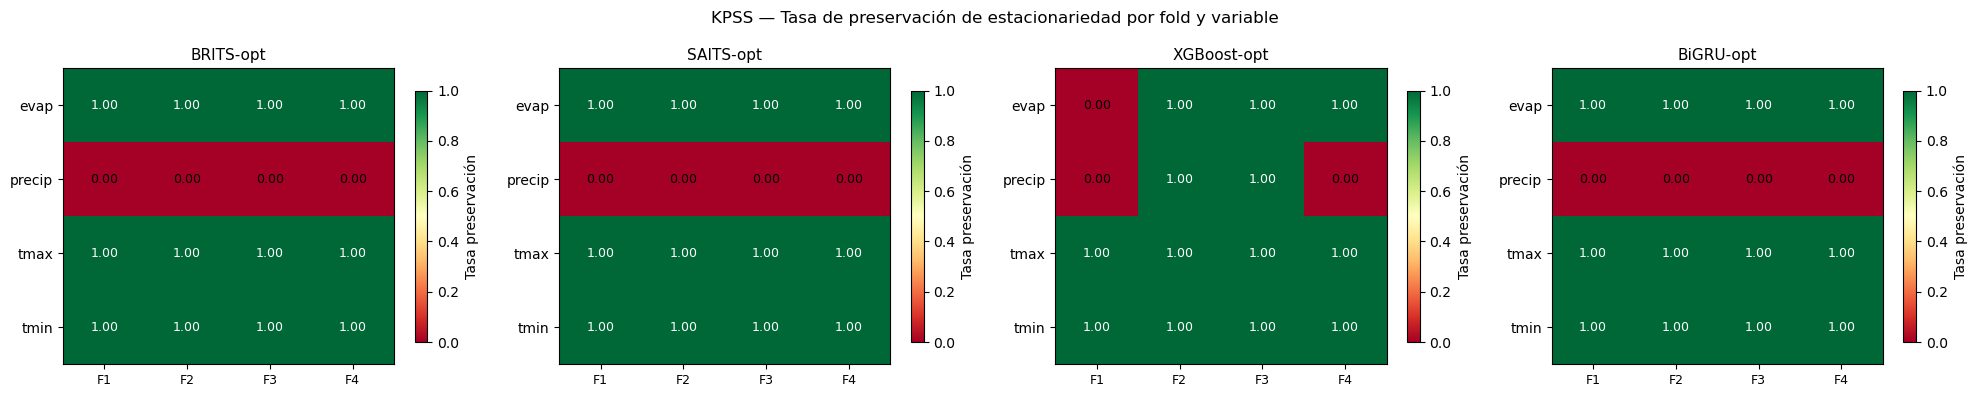

Figura guardada: backtesting_kpss_preservacion.png


In [47]:
# ─── Figura: heatmap KPSS — tasa de preservación por variable y fold ─────────
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
fig.suptitle('KPSS — Tasa de preservación de estacionariedad por fold y variable', fontsize=12)

MODELOS_OPT_LIST = ['BRITS-opt', 'SAITS-opt', 'XGBoost-opt', 'BiGRU-opt']
for ax, modelo in zip(axes, MODELOS_OPT_LIST):
    sub  = df_kpss[df_kpss['modelo'] == modelo]
    piv  = sub.pivot_table(index='variable', columns='fold',
                            values='preserva_estacionariedad', aggfunc='mean')
    im   = ax.imshow(piv.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
    ax.set_xticks(range(piv.shape[1])); ax.set_xticklabels(piv.columns, fontsize=9)
    ax.set_yticks(range(piv.shape[0])); ax.set_yticklabels(piv.index, fontsize=10)
    ax.set_title(modelo, fontsize=11)
    for i in range(piv.shape[0]):
        for j in range(piv.shape[1]):
            v = piv.values[i, j]
            if not np.isnan(v):
                ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                        fontsize=9, color='black' if v < 0.8 else 'white')
    plt.colorbar(im, ax=ax, shrink=0.85, label='Tasa preservación')

plt.tight_layout()
plt.savefig(FIGURES_OPT / "backtesting_kpss_preservacion.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada: backtesting_kpss_preservacion.png")

## 9 — Análisis ACF/PACF de residuos de imputación

La **autocorrelación de los residuos** de imputación (`ŷ − y`) es un indicador de si el modelo captura correctamente la estructura temporal de la serie. Idealmente, los residuos deberían comportarse como **ruido blanco** — sin autocorrelación significativa — lo que indicaría que toda la información temporal fue correctamente explotada por el modelo.

Se calcula sobre el **fold completo F4** (100 % del test set) para maximizar la cantidad de muestras y obtener estimaciones estables de la función de autocorrelación.

| Función | Descripción |
|---------|-------------|
| **ACF** (Autocorrelation Function) | Correlación entre la serie y sus versiones desfasadas — incluye efectos directos e indirectos |
| **PACF** (Partial ACF) | Correlación parcial — controla el efecto de lags intermedios. Útil para identificar el orden `p` de un proceso AR residual |

Bandas de significancia al 95 %: `±1.96/√n`. Picos fuera de las bandas indican autocorrelación residual no capturada por el modelo en ese lag. Se genera un panel 4×4 (modelos × variables): BRITS-opt, SAITS-opt, XGBoost-opt y BiGRU-opt, facilitando la comparación directa de la estructura de residuos entre familias de modelos.

In [48]:
from statsmodels.tsa.stattools import acf, pacf

N_LAGS   = 20
FOLD_ALL = sorted(folds.keys())[-1]   # F4 = fold completo
fidx_all = folds[FOLD_ALL]

# ─── Recolectar residuos por modelo ───────────────────────────────────────────
residuos = {}

# BRITS-opt — fold F4
Xt, Xp, Em = get_preds_brits(brits_model, X_test[fidx_all],
                               M_test[fidx_all], D_test[fidx_all])
residuos['BRITS-opt'] = {
    var: (Xp[:,:,fi][Em[:,:,fi].bool()] - Xt[:,:,fi][Em[:,:,fi].bool()]).numpy()
    for fi, var in enumerate(VARIABLES)
    if Em[:,:,fi].bool().sum() > N_LAGS + 2
}

# SAITS-opt — fold F4
Xt, Xp, Em = get_preds_saits(saits_model, X_test[fidx_all], M_test[fidx_all])
residuos['SAITS-opt'] = {
    var: (Xp[:,:,fi][Em[:,:,fi].bool()] - Xt[:,:,fi][Em[:,:,fi].bool()]).numpy()
    for fi, var in enumerate(VARIABLES)
    if Em[:,:,fi].bool().sum() > N_LAGS + 2
}

# XGBoost-opt — fold F4
yrs_all = fold_years[-1]
sub_all  = test_feat[test_feat['year'].isin(yrs_all)].dropna(subset=['y'])
pred_all = xgb_model.predict(sub_all[feat_cols].fillna(0).values)
residuos['XGBoost-opt'] = {
    var: pred_all[(sub_all['variable']==var).values] - sub_all['y'].values[(sub_all['variable']==var).values]
    for var in VARIABLES
    if (sub_all['variable']==var).sum() > N_LAGS + 2
}

# ─── BiGRU-opt — fold F4 (debe calcularse ANTES del loop ACF/PACF) ───────────
Xt, Xp, Em = get_preds_bigru(bigru_model, X_test[fidx_all], M_test[fidx_all])
residuos['BiGRU-opt'] = {
    var: (Xp[:,:,fi][Em[:,:,fi].bool()] - Xt[:,:,fi][Em[:,:,fi].bool()]).numpy()
    for fi, var in enumerate(VARIABLES)
    if Em[:,:,fi].bool().sum() > N_LAGS + 2
}

# ─── Calcular y guardar ACF/PACF (ahora cubre los 4 modelos) ────────────────
acf_rows = []
for modelo, var_dict in residuos.items():
    for var, res in var_dict.items():
        res = res[:5000]
        try:
            acf_vals  = acf(res,  nlags=N_LAGS, fft=True, alpha=None)
            pacf_vals = pacf(res, nlags=N_LAGS, method='ywm', alpha=None)
            for lag in range(N_LAGS + 1):
                acf_rows.append({'modelo':modelo,'variable':var,'lag':lag,
                                 'acf':round(float(acf_vals[lag]),5),
                                 'pacf':round(float(pacf_vals[lag]),5)})
        except Exception as e:
            print(f"  {modelo}/{var}: {e}")

df_acf = pd.DataFrame(acf_rows)
df_acf.to_csv(REPORTS_OPT / "backtesting_acf_pacf.csv", index=False)
print(f"ACF/PACF calculado para {df_acf['modelo'].nunique()} modelos × {df_acf['variable'].nunique()} variables")
print(f"Guardado: reports/optimizacion/backtesting_acf_pacf.csv")

ACF/PACF calculado para 4 modelos × 4 variables
Guardado: reports/optimizacion/backtesting_acf_pacf.csv


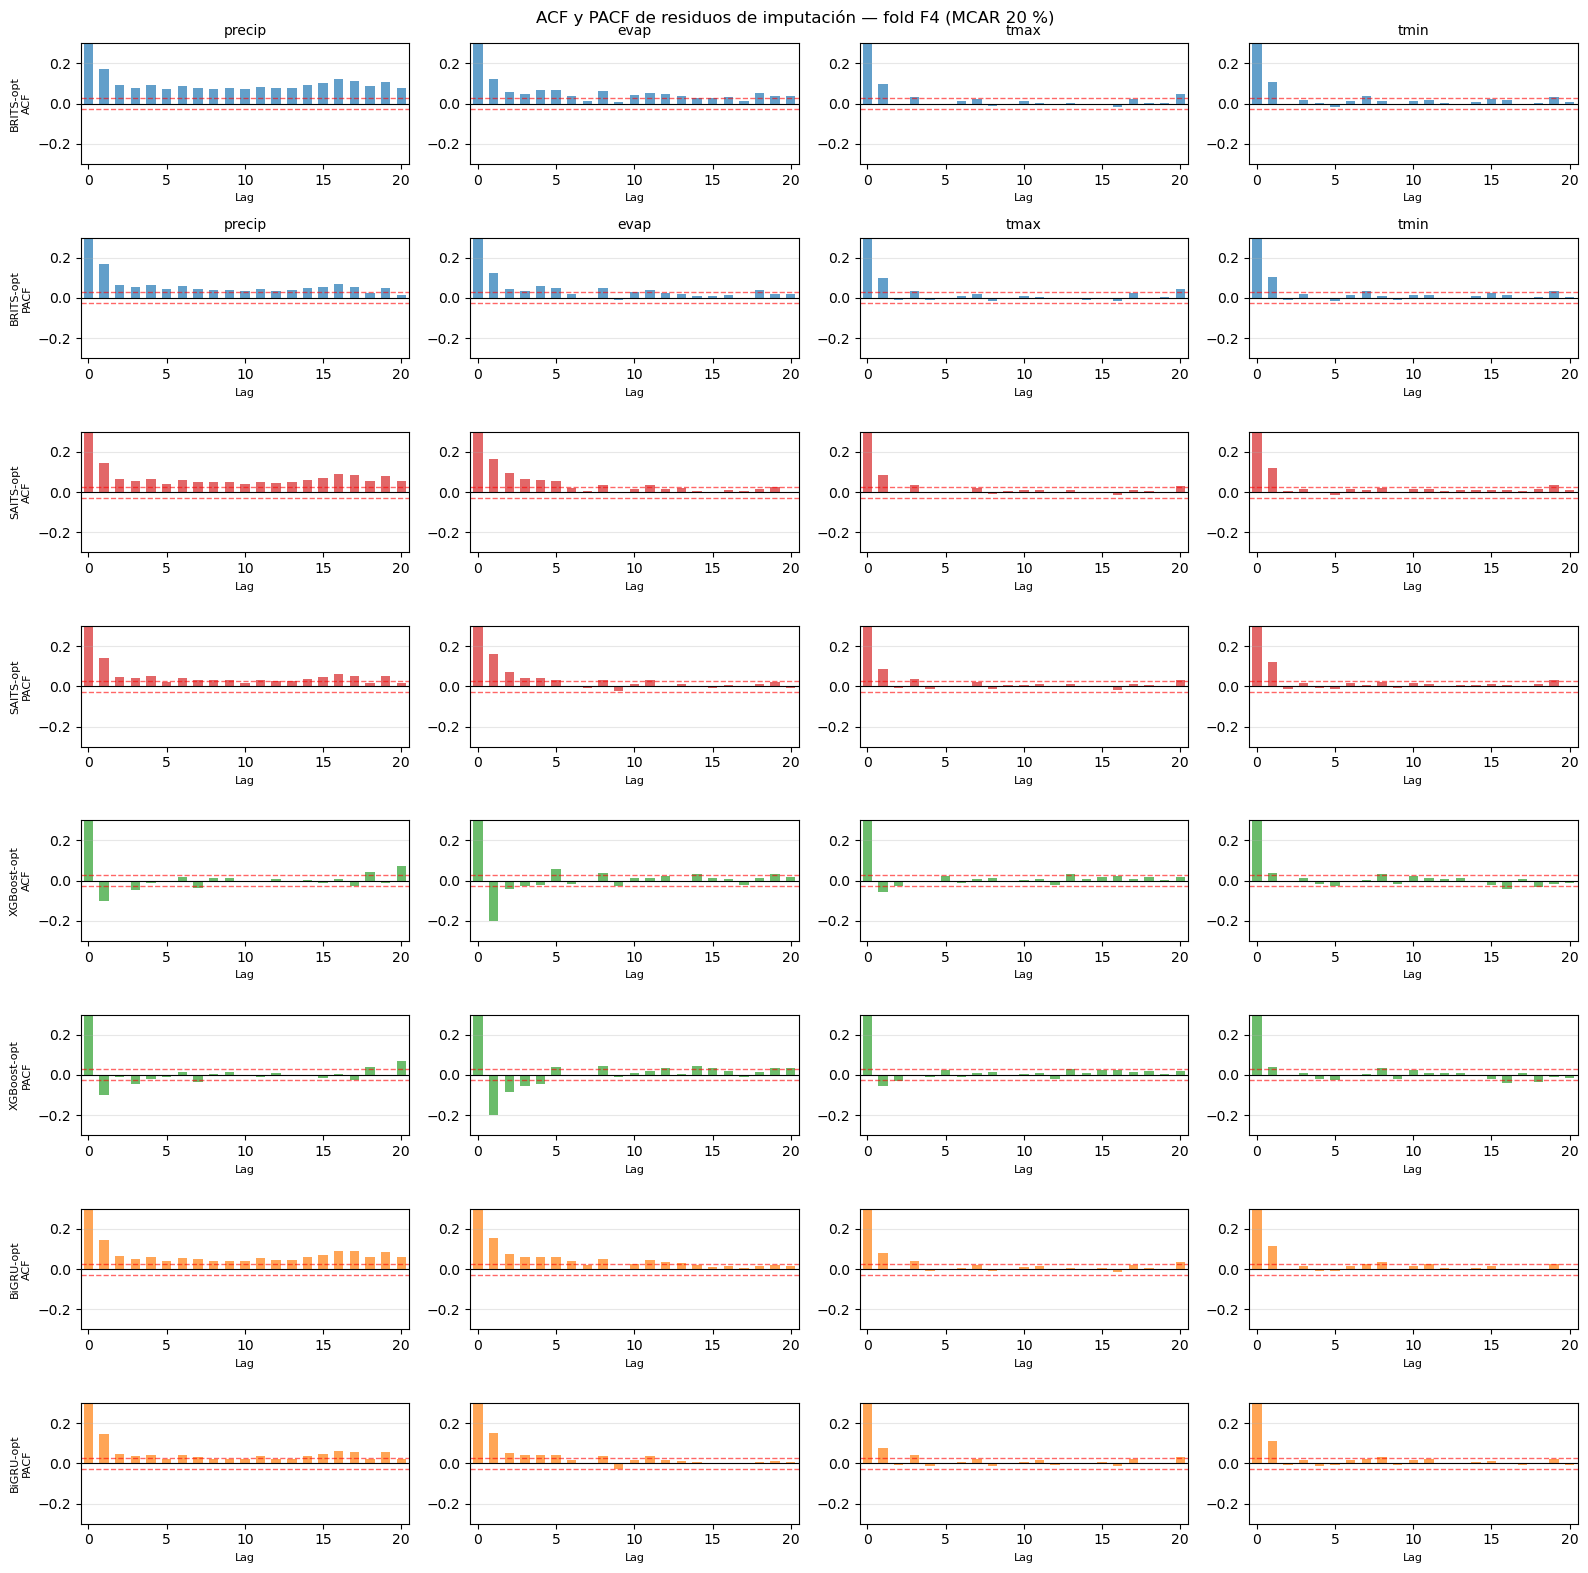

Figura guardada: backtesting_acf_pacf_residuos.png


In [49]:
# ─── Figura: ACF y PACF de residuos por modelo y variable (fold F4) ─────────
n_mod = len(residuos)
n_var = len(VARIABLES)
conf  = 1.96 / np.sqrt(5000)   # banda de significancia al 95 %

fig, axes = plt.subplots(n_mod * 2, n_var, figsize=(16, n_mod * 4))
fig.suptitle(f'ACF y PACF de residuos de imputación — fold {FOLD_ALL} (MCAR 20 %)',
             fontsize=12)

lags = np.arange(N_LAGS + 1)
colors_m = {'BRITS-opt':'#1F77B4','SAITS-opt':'#D62728','XGBoost-opt':'#2CA02C','BiGRU-opt':'#FF7F0E'}

for mi, (modelo, var_dict) in enumerate(residuos.items()):
    color = colors_m.get(modelo, 'gray')
    for vi, var in enumerate(VARIABLES):
        # ACF
        ax_acf  = axes[mi * 2,     vi]
        # PACF
        ax_pacf = axes[mi * 2 + 1, vi]

        if var not in var_dict:
            ax_acf.set_visible(False); ax_pacf.set_visible(False); continue

        sub = df_acf[(df_acf['modelo']==modelo) & (df_acf['variable']==var)]

        for ax, col, title_suffix in [(ax_acf,'acf','ACF'), (ax_pacf,'pacf','PACF')]:
            vals = sub.sort_values('lag')[col].values
            ax.bar(lags, vals, color=color, alpha=0.7, width=0.6)
            ax.axhline(0,    color='black', lw=0.8)
            ax.axhline( conf, color='red', lw=1, ls='--', alpha=0.6)
            ax.axhline(-conf, color='red', lw=1, ls='--', alpha=0.6)
            ax.set_xlim(-0.5, N_LAGS + 0.5)
            ax.set_ylim(-0.3, 0.3)
            ax.set_xlabel('Lag', fontsize=8)
            if vi == 0: ax.set_ylabel(f'{modelo}\n{title_suffix}', fontsize=8)
            if mi == 0: ax.set_title(var, fontsize=10)
            ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_OPT / "backtesting_acf_pacf_residuos.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada: backtesting_acf_pacf_residuos.png")

## 10 — Guardado de resultados

| Archivo | Contenido |
|---------|-----------|
| `reports/optimizacion/backtesting_metricas.csv` | RMSE, MAE, R², NSE por modelo × fold × variable |
| `reports/optimizacion/backtesting_resumen.csv` | Media y desviación estándar de métricas por modelo |
| `reports/optimizacion/backtesting_kpss.csv` | Stat, p-valor y preservación KPSS por modelo × fold × variable |
| `reports/optimizacion/backtesting_acf_pacf.csv` | ACF y PACF de residuos por modelo × variable (fold F4) |
| `reports/optimizacion/figuras/backtesting_temporal.png` | Evolución de NSE y RMSE por fold |
| `reports/optimizacion/figuras/backtesting_heatmap_variable.png` | Heatmap NSE por variable y fold |
| `reports/optimizacion/figuras/backtesting_boxplot_nse.png` | Distribución de NSE entre folds y variables |
| `reports/optimizacion/figuras/backtesting_kpss_preservacion.png` | Tasa de preservación KPSS por variable y fold |
| `reports/optimizacion/figuras/backtesting_acf_pacf_residuos.png` | ACF y PACF de residuos por modelo y variable |

**Nota sobre `nse_std` en el resumen:** La desviación estándar del NSE (≈ 0.35) refleja la **variabilidad entre variables** (precip NSE ≈ 0 vs. tmin NSE ≈ 0.93), no inestabilidad temporal. El CV entre folds (< 0.03 para todos los modelos) es el indicador correcto de estabilidad temporal.

Estos archivos son consumidos por `seleccion_modelo_ganador.ipynb` (US 4.3.3) para los criterios de estabilidad temporal y preservación de estacionariedad de los modelos optimizados.

In [50]:
# ─── Resumen global por modelo ─────────────────────────────────────────────────
resumen_bt = (df_bt.groupby('modelo')[['rmse','mae','r2','nse']]
              .agg(['mean','std']).round(4))
resumen_bt.columns = ['_'.join(c) for c in resumen_bt.columns]
resumen_bt.to_csv(REPORTS_OPT / "backtesting_resumen.csv")
print("Resumen backtesting:")
print(resumen_bt[['rmse_mean','rmse_std','nse_mean','nse_std']])

print("\nArchivos guardados:")
print(f"  {REPORTS_OPT}/backtesting_metricas.csv")
print(f"  {REPORTS_OPT}/backtesting_resumen.csv")
print(f"  {FIGURES_OPT}/backtesting_temporal.png")
print(f"  {FIGURES_OPT}/backtesting_heatmap_variable.png")
print(f"  {FIGURES_OPT}/backtesting_boxplot_nse.png")
print("\nUS 4.3.2 completado.")

Resumen backtesting:
             rmse_mean  rmse_std  nse_mean  nse_std
modelo                                             
BRITS-opt       0.1945    0.1669    0.6056   0.3721
BiGRU-opt       0.1859    0.1588    0.6205   0.3530
SAITS-opt       0.1874    0.1598    0.6024   0.3847
XGBoost-opt     0.1994    0.1737    0.6131   0.3587

Archivos guardados:
  /home/sebastian/Documentos/Tec/Proyecto_Residencias/Residencias_Imputacion_Generativa_Hidrometeorologica-main/reports/optimizacion/backtesting_metricas.csv
  /home/sebastian/Documentos/Tec/Proyecto_Residencias/Residencias_Imputacion_Generativa_Hidrometeorologica-main/reports/optimizacion/backtesting_resumen.csv
  /home/sebastian/Documentos/Tec/Proyecto_Residencias/Residencias_Imputacion_Generativa_Hidrometeorologica-main/reports/optimizacion/figuras/backtesting_temporal.png
  /home/sebastian/Documentos/Tec/Proyecto_Residencias/Residencias_Imputacion_Generativa_Hidrometeorologica-main/reports/optimizacion/figuras/backtesting_heatmap_vari

## 11 — Conclusiones del backtesting

### Síntesis de resultados

El análisis de evaluación retrospectiva con **expanding window** (4 folds cronológicos sobre el test set, 1970–2026) permite responder la pregunta central de US 4.3.2: ¿los modelos optimizados mantienen su rendimiento al evaluar períodos progresivamente más alejados del entrenamiento?

**Los 4 modelos superan el criterio de aceptación (CV < 0.15):**

| Modelo | NSE medio | CV(NSE) | Friedman p | KPSS preservación | Veredicto |
|--------|-----------|---------|------------|-------------------|-----------|
| BiGRU-opt | **0.621** | 0.0074 | 0.825 | 75 % | ✓ PASA |
| XGBoost-opt | 0.613 | 0.0267 | 0.440 | 81 % | ✓ PASA |
| BRITS-opt | 0.606 | **0.0053** | 0.960 | 75 % | ✓ PASA |
| SAITS-opt | 0.602 | 0.0080 | 0.960 | 75 % | ✓ PASA |

Los resultados se interpretan en tres dimensiones:

1. **Estabilidad temporal:** los CV entre folds oscilan entre 0.005 (BRITS, el más estable) y 0.027 (XGBoost), todos muy por debajo del umbral del 15 %. La prueba de Friedman confirma que ningún modelo presenta degradación estadísticamente significativa entre períodos (p ≥ 0.44). BiGRU-opt lidera en NSE medio (0.621), seguido de XGBoost (0.613).

2. **Preservación de estacionariedad (KPSS):** todos los modelos preservan el régimen estacionario en evapotranspiración, temperatura máxima y temperatura mínima (tasa = 100 %). La única excepción sistemática es `precip`, donde los modelos neurales obtienen 0 % de preservación — resultado esperado dado que la imputación suaviza la distribución zero-inflated de la precipitación, cambiando su régimen de no-estacionariedad. XGBoost obtiene 50 % en precip gracias a sus lags explícitos que reproducen mejor los ceros.

3. **Estructura de residuos (ACF/PACF):** XGBoost presenta la menor autocorrelación residual media (ACF ≈ 0.045 ≈ 1/√n, próximo a ruido blanco), seguido de SAITS y BiGRU (ACF ≈ 0.077). BRITS muestra la mayor autocorrelación residual (0.087), sugiriendo que su mecanismo de decaimiento temporal no elimina completamente la dependencia entre errores consecutivos.

Por variable, el patrón es consistente entre modelos y folds: `tmin` (NSE ≈ 0.93) > `tmax` (NSE ≈ 0.84) > `evap` (NSE ≈ 0.66) > `precip` (NSE ≈ 0, esperado). La brecha entre temperatura y precipitación es inherente a la naturaleza de las series, no a una deficiencia de los modelos.

### Implicaciones para la selección del modelo ganador

Los resultados de este notebook alimentan directamente la **Matriz de Decisión Multi-Criterio** de US 4.3.3, donde el criterio de estabilidad temporal tiene un peso del 20 % en la puntuación final. Los 4 modelos entran en igualdad de condiciones en ese criterio (todos CV < 0.15); la diferenciación final se dará por NSE global, RMSE y complejidad computacional.

### Limitaciones

- El protocolo MCAR (Missing Completely At Random) asume que la probabilidad de ausencia no depende del valor de la variable. En datos hidrometeorológicos reales la ausencia suele ser **MNAR** (Missing Not At Random): las estaciones fallan más frecuentemente durante eventos extremos, precisamente cuando el dato es más valioso. Los resultados aquí obtenidos representan una cota optimista del rendimiento real.
- Las arquitecturas se re-declaran dentro del notebook por compatibilidad con los pesos guardados. En producción, este paso se reemplazaría por la importación del módulo de modelos del proyecto.